# Implement a VAE for image generation

## Our Architecture

- Encoder: Maps an input image $x$ to latent space parameters—mean ($\mu$) and log variance ($\log \sigma^2$).

- Reparameterization Trick: Samples latent vector $z = \mu + \sigma \odot \epsilon$ (where $\epsilon \sim \mathcal{N}(0, I)$) to allow backpropagation through the stochastic sampling step.


- Decoder: Reconstructs the image $\hat{x}$ from the sampled latent vector $z$.

- Loss Function: Combines Reconstruction Loss (Binary Cross Entropy) and Kullback-Leibler (KL) Divergence to penalize latent distributions that deviate from a standard Gaussian prior $\mathcal{N}(0, I)$.



Using device: cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.6MB/s]


Starting Training...
Epoch [1/15] | Average Loss per Image: 284.2429
Epoch [2/15] | Average Loss per Image: 254.1800
Epoch [3/15] | Average Loss per Image: 250.4930
Epoch [4/15] | Average Loss per Image: 248.4901
Epoch [5/15] | Average Loss per Image: 247.1301
Epoch [6/15] | Average Loss per Image: 246.2264
Epoch [7/15] | Average Loss per Image: 245.4975
Epoch [8/15] | Average Loss per Image: 244.9251
Epoch [9/15] | Average Loss per Image: 244.3746
Epoch [10/15] | Average Loss per Image: 243.9687
Epoch [11/15] | Average Loss per Image: 243.5531
Epoch [12/15] | Average Loss per Image: 243.2090
Epoch [13/15] | Average Loss per Image: 242.9924
Epoch [14/15] | Average Loss per Image: 242.6419
Epoch [15/15] | Average Loss per Image: 242.4089
Training Complete!


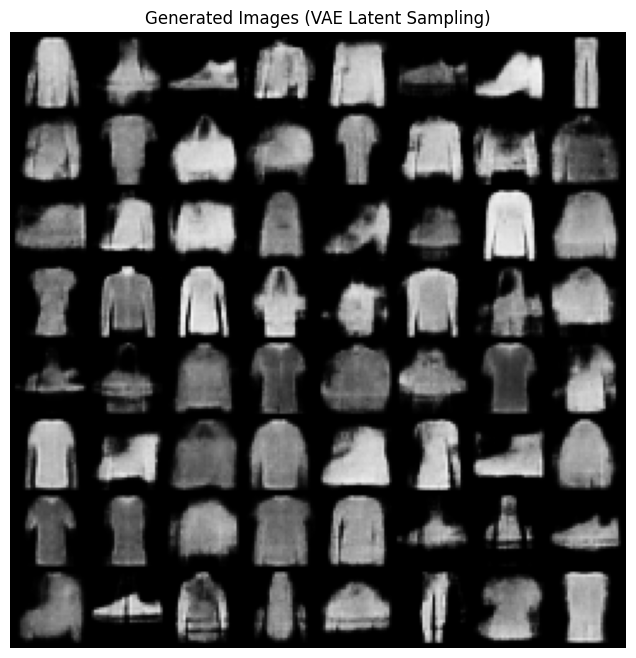

In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# ---------------------------------------------------------
# 1. Hyperparameters & Device Setup
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

latent_dim = 20        # Dimension of continuous latent space z
batch_size = 128
lr = 0.001             # Adam learning rate
epochs = 15            # Trains in ~1-2 mins on Colab T4 GPU

# ---------------------------------------------------------
# 2. Data Preparation
# ---------------------------------------------------------
# Standard normalization to range [0, 1] for BCE loss evaluation
transform = transforms.ToTensor()

dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# ---------------------------------------------------------
# 3. Model Architecture
# ---------------------------------------------------------
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()

        # --- Encoder Network ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # -> 32 x 14 x 14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # -> 64 x 7 x 7
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Flatten()                                          # -> 64 * 7 * 7 = 3136
        )

        # Latent space parameter projections
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        # --- Decoder Network ---
        self.decoder_fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 32 x 14 x 14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 1 x 28 x 28
            nn.Sigmoid()                                                                      # Scale outputs to [0, 1]
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        """
        Reparameterization Trick: z = mu + std * epsilon
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(-1, 64, 7, 7)
        return self.decoder_conv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

# ---------------------------------------------------------
# 4. Loss Function
# ---------------------------------------------------------
def loss_function(recon_x, x, mu, logvar):
    # 1. Reconstruction Loss (Binary Cross-Entropy)
    bce_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # 2. KL Divergence: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return bce_loss + kld_loss

model = VAE(latent_dim=latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

# ---------------------------------------------------------
# 5. Training Loop
# ---------------------------------------------------------
print("Starting Training...")

model.train()
for epoch in range(epochs):
    total_loss = 0
    for i, (images, _) in enumerate(dataloader):
        images = images.to(device)

        optimizer.zero_grad()
        recon_images, mu, logvar = model(images)

        loss = loss_function(recon_images, images, mu, logvar)
        loss.backward()

        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}] | Average Loss per Image: {avg_loss:.4f}")

print("Training Complete!")

# ---------------------------------------------------------
# 6. Generate New Images from Latent Prior N(0, I)
# ---------------------------------------------------------
model.eval()
with torch.no_grad():
    # Sample random latent vectors directly from standard normal distribution
    z_sampled = torch.randn(64, latent_dim, device=device)
    generated_imgs = model.decode(z_sampled).cpu()

# Plot 64 generated images as an 8x8 grid
grid = vutils.make_grid(generated_imgs, padding=2, normalize=False)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Images (VAE Latent Sampling)")
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.show()

## To generate images using a pretrained VAE

Cell 1: Install Dependencies
Installs Hugging Face diffusers (for the VAE) and min-dalle / transformers along with standard vision libraries.

In [ ]:
# Cell 1: Install required libraries
!pip install -q diffusers transformers accelerate safetensors torchvision

Cell 2: Load Libraries & Configure Device

In [ ]:
# Cell 2: Verify GPU availability and import PyTorch
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on device: {device}")

Running on device: cuda


Cell 3: Generative Image Synthesis with a PretrainedVAE

Demonstrates pure generative decoding: We sample random Gaussian noise directly in the VAE's latent space ($\mathbf{z} \sim \mathcal{N}(0, \mathbf{I})$) and pass it through the VAE Decoder to produce an image.

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


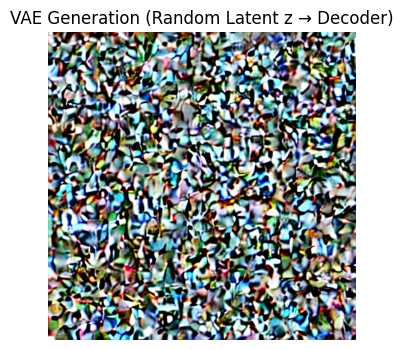

In [ ]:
# Cell 3: VAE Image Generation from Latent Space
from diffusers import AutoencoderKL
import numpy as np

# 1. Load Pretrained Latent Diffusion VAE (SD v1.5 VAE backbone)
vae = AutoencoderKL.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    subfolder="vae",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
).to(device)

vae.eval()

# 2. Sample random latent noise z ~ N(0, I)
# The VAE expects latents of shape: (batch_size, channels, height, width) -> (1, 4, 64, 64)
torch.manual_seed(42)
latent_sample = torch.randn((1, 4, 64, 64), device=device, dtype=vae.dtype)

# 3. Decode latent vector directly to RGB pixel space (Single Pass Decoding)
with torch.no_grad():
    # Scale latents using SD VAE scaling factor
    decoded_tensor = vae.decode(latent_sample / vae.config.scaling_factor).sample

# 4. Normalize pixel values from [-1, 1] to [0, 1] and convert to float32 for plotting
decoded_image = (decoded_tensor / 2.0 + 0.5).clamp(0, 1)
decoded_image = decoded_image.squeeze(0).cpu().permute(1, 2, 0).numpy().astype(np.float32)

# Plot Generated VAE Output
plt.figure(figsize=(4, 4))
plt.imshow(decoded_image)
plt.title("VAE Generation (Random Latent z → Decoder)")
plt.axis("off")
plt.show()

### Batch VAE Sample Generation

This cell demonstrates generating multiple VAE samples in a single batch operation and displaying them in a grid.

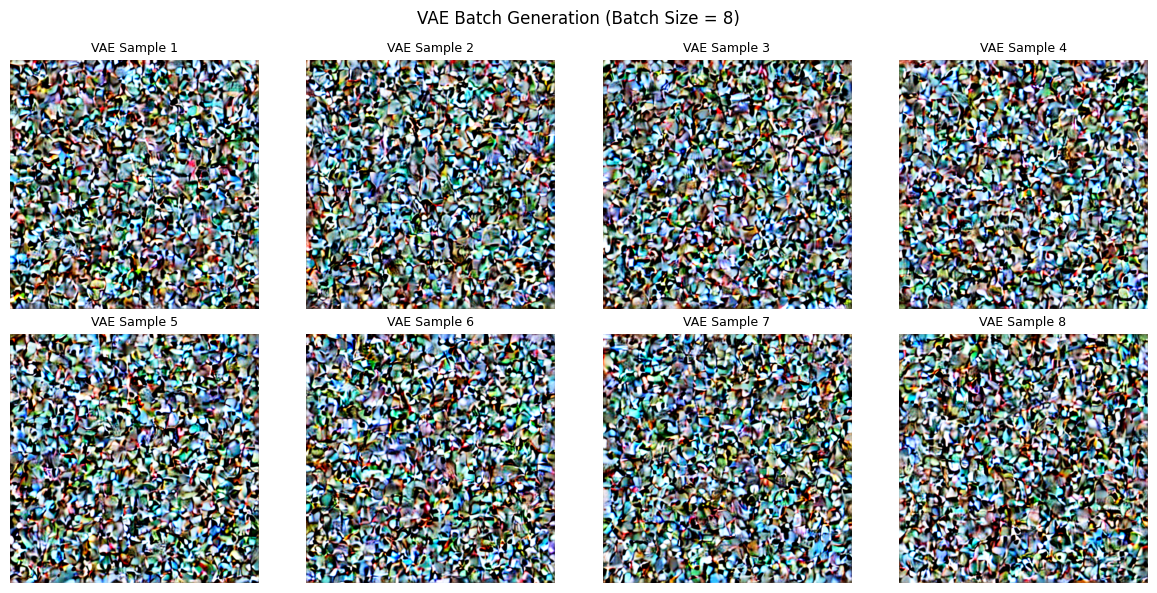

In [ ]:
batch_size = 8

# 1. Sample a batch of random latent noise vectors
torch.manual_seed(43) # Using a new seed for different samples
batch_latent_sample = torch.randn((batch_size, 4, 64, 64), device=device, dtype=vae.dtype)

# 2. Decode the batch of latent vectors
with torch.no_grad():
    batch_decoded_tensor = vae.decode(batch_latent_sample / vae.config.scaling_factor).sample

# 3. Normalize pixel values and convert to NumPy for plotting
batch_decoded_images = (batch_decoded_tensor / 2.0 + 0.5).clamp(0, 1)

# Create a grid for plotting
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten() # Flatten the 2x4 array of axes for easy iteration

for i in range(batch_size):
    img = batch_decoded_images[i].squeeze(0).cpu().permute(1, 2, 0).numpy().astype(np.float32)
    axes[i].imshow(img)
    axes[i].set_title(f"VAE Sample {i+1}", fontsize=9)
    axes[i].axis("off")

plt.suptitle(f"VAE Batch Generation (Batch Size = {batch_size})", fontsize=12)
plt.tight_layout()
plt.show()

VAE Sampling Observation:

Sampling a random vector $\mathbf{z} \sim \mathcal{N}(0, \mathbf{I})$ directly into a VAE decoder produces smooth, structured textures (or abstract color patches) because the VAE latent space is continuous and regularized by KL divergence.


